In [6]:
import trimesh as tm
import numpy as np
import pykarambola
import pandas as pd
import time
import matplotlib.pyplot as plt

In [2]:
R = 1

In [ ]:
# Function to calculate beta value (min/max of eigenvalues)
def calculate_beta(eigenvalues):
    return min(np.abs(eigenvalues)) / max(np.abs(eigenvalues))

# Cython

In [7]:
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []
timing = []

In [ ]:
for sub in range(5, 12):
    s = tm.creation.icosphere(sub, radius=R)
    n_verts = len(s.vertices)
    print(f'Subdivision: {sub} | Vertices: {n_verts}')

    t_start = time.time()

    poly_verts, poly_faces = s.vertices, s.faces
    result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

    t_end = time.time()
    elapsed = t_end - t_start
    print(f'  → Time taken: {elapsed:.4f}s')

    timing.append({'subdivision': sub, 'n_vertices': n_verts, 'time_s': elapsed})

    row = {'subdivision': sub, 'n_vertices': n_verts}

    for skey in ['w000', 'w100', 'w200', 'w300']:
        row[skey] = result[skey]

    for vkey in vector_keys:
        vec = result[vkey]
        row[f'{vkey}_0'] = vec[0]
        row[f'{vkey}_1'] = vec[1]
        row[f'{vkey}_2'] = vec[2]

    for tkey in tensor_keys:
        mat = result[tkey]
        row[f'{tkey}_00'] = mat[0, 0]
        row[f'{tkey}_01'] = mat[0, 1]
        row[f'{tkey}_02'] = mat[0, 2]
        row[f'{tkey}_11'] = mat[1, 1]
        row[f'{tkey}_12'] = mat[1, 2]
        row[f'{tkey}_22'] = mat[2, 2]

    for tkey in tensor_keys:
        eigvals = result[f'{tkey}_eigvals']
        row[f'beta_{tkey}']  = calculate_beta(eigvals)
        row[f'{tkey}_EVal1'] = eigvals[0]
        row[f'{tkey}_EVal2'] = eigvals[1]
        row[f'{tkey}_EVal3'] = eigvals[2]

    records.append(row)

# ── Results DataFrame ─────────────────────────────────────────────────────────
cols = [
    'subdivision', 'n_vertices',
    'w000', 'w100', 'w200', 'w300',
    'w010_0', 'w010_1', 'w010_2',
    'w110_0', 'w110_1', 'w110_2',
    'w210_0', 'w210_1', 'w210_2',
    'w310_0', 'w310_1', 'w310_2',
    'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
    'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
    'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
    'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
    'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
    'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
    'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
    'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
    'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
    'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
    'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
    'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
    'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
]
df_cy = pd.DataFrame(records)[cols]
df_cy.to_csv('../dataframes/minkowski_tensors_with_eigen_vals_pykarambola_cython.csv', index=False)
print(f"\nSaved {len(df_cy)} rows")
print(df_cy.head())

# ── Timing Summary ────────────────────────────────────────────────────────────
df_timing = pd.DataFrame(timing)
print("\nTiming summary:")
print(df_timing.to_string(index=False))
df_timing.to_csv('../dataframes/timing_summary_cython.csv', index=False)

Subdivision: 5 | Vertices: 10242
  → Time taken: 0.0770s
Subdivision: 6 | Vertices: 40962
  → Time taken: 0.2806s
Subdivision: 7 | Vertices: 163842
  → Time taken: 1.1146s
Subdivision: 8 | Vertices: 655362
  → Time taken: 4.6215s
Subdivision: 9 | Vertices: 2621442
  → Time taken: 19.5776s
Subdivision: 10 | Vertices: 10485762
  → Time taken: 85.0628s
Subdivision: 11 | Vertices: 41943042
  → Time taken: 1131.7903s

Saved 7 rows
   subdivision  n_vertices      w000      w100      w200     w300  \
0            5       10242  4.186525  4.187538  4.188373  4.18879   
1            6       40962  4.188224  4.188477  4.188686  4.18879   
2            7      163842  4.188649  4.188712  4.188764  4.18879   
3            8      655362  4.188755  4.188771  4.188784  4.18879   
4            9     2621442  4.188781  4.188785  4.188789  4.18879   

         w010_0        w010_1        w010_2        w110_0  ...  w120_EVal3  \
0 -5.072846e-16 -1.092648e-15  2.220684e-16  1.839078e-15  ...    1.395343   

with vertices length 167772162, subdivision 12, the kernel crashed even with cython. It crashed so bad, it even corrupted my git!
with vertices length 10485762, subdivision 10, it took 1 min and 22 seconds.

# Vectorized

In [4]:
tensor_keys = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
vector_keys = ['w010', 'w110', 'w210', 'w310']

records = []
timing = []

In [ ]:
for sub in range(5, 12):
    s = tm.creation.icosphere(sub, radius=R)
    n_verts = len(s.vertices)
    print(f'Subdivision: {sub} | Vertices: {n_verts}')

    t_start = time.time()

    poly_verts, poly_faces = s.vertices, s.faces
    result = pykarambola.minkowski_functionals(poly_verts, poly_faces)

    t_end = time.time()
    elapsed = t_end - t_start
    print(f'  → Time taken: {elapsed:.4f}s')

    timing.append({'subdivision': sub, 'n_vertices': n_verts, 'time_s': elapsed})

    row = {'subdivision': sub, 'n_vertices': n_verts}

    for skey in ['w000', 'w100', 'w200', 'w300']:
        row[skey] = result[skey]

    for vkey in vector_keys:
        vec = result[vkey]
        row[f'{vkey}_0'] = vec[0]
        row[f'{vkey}_1'] = vec[1]
        row[f'{vkey}_2'] = vec[2]

    for tkey in tensor_keys:
        mat = result[tkey]
        row[f'{tkey}_00'] = mat[0, 0]
        row[f'{tkey}_01'] = mat[0, 1]
        row[f'{tkey}_02'] = mat[0, 2]
        row[f'{tkey}_11'] = mat[1, 1]
        row[f'{tkey}_12'] = mat[1, 2]
        row[f'{tkey}_22'] = mat[2, 2]

    for tkey in tensor_keys:
        eigvals = result[f'{tkey}_eigvals']
        row[f'beta_{tkey}']  = calculate_beta(eigvals)
        row[f'{tkey}_EVal1'] = eigvals[0]
        row[f'{tkey}_EVal2'] = eigvals[1]
        row[f'{tkey}_EVal3'] = eigvals[2]

    records.append(row)

# ── Results DataFrame ─────────────────────────────────────────────────────────
cols = [
    'subdivision', 'n_vertices',
    'w000', 'w100', 'w200', 'w300',
    'w010_0', 'w010_1', 'w010_2',
    'w110_0', 'w110_1', 'w110_2',
    'w210_0', 'w210_1', 'w210_2',
    'w310_0', 'w310_1', 'w310_2',
    'w020_00', 'w020_01', 'w020_02', 'w020_11', 'w020_12', 'w020_22',
    'w120_00', 'w120_01', 'w120_02', 'w120_11', 'w120_12', 'w120_22',
    'w220_00', 'w220_01', 'w220_02', 'w220_11', 'w220_12', 'w220_22',
    'w320_00', 'w320_01', 'w320_02', 'w320_11', 'w320_12', 'w320_22',
    'w102_00', 'w102_01', 'w102_02', 'w102_11', 'w102_12', 'w102_22',
    'w202_00', 'w202_01', 'w202_02', 'w202_11', 'w202_12', 'w202_22',
    'beta_w020', 'beta_w102', 'beta_w120', 'beta_w202', 'beta_w220', 'beta_w320',
    'w020_EVal1', 'w020_EVal2', 'w020_EVal3',
    'w102_EVal1', 'w102_EVal2', 'w102_EVal3',
    'w120_EVal1', 'w120_EVal2', 'w120_EVal3',
    'w202_EVal1', 'w202_EVal2', 'w202_EVal3',
    'w220_EVal1', 'w220_EVal2', 'w220_EVal3',
    'w320_EVal1', 'w320_EVal2', 'w320_EVal3',
]
df_cy = pd.DataFrame(records)[cols]
df_cy.to_csv('../dataframes/minkowski_tensors_with_eigen_vals_pykarambola_vectorized.csv', index=False)
print(f"\nSaved {len(df_cy)} rows")
print(df_cy.head())

# ── Timing Summary ────────────────────────────────────────────────────────────
df_timing = pd.DataFrame(timing)
print("\nTiming summary:")
print(df_timing.to_string(index=False))
df_timing.to_csv('../dataframes/timing_summary_vectorized.csv', index=False)

Subdivision: 5 | Vertices: 10242
  → Time taken: 0.0674s
Subdivision: 6 | Vertices: 40962
  → Time taken: 0.2660s
Subdivision: 7 | Vertices: 163842
  → Time taken: 1.1013s
Subdivision: 8 | Vertices: 655362
  → Time taken: 4.6910s
Subdivision: 9 | Vertices: 2621442
  → Time taken: 19.2272s
Subdivision: 10 | Vertices: 10485762
  → Time taken: 88.0650s
Subdivision: 11 | Vertices: 41943042
  → Time taken: 1213.4243s

Saved 7 rows
   subdivision  n_vertices      w000      w100      w200     w300  \
0            5       10242  4.186525  4.187538  4.188373  4.18879   
1            6       40962  4.188224  4.188477  4.188686  4.18879   
2            7      163842  4.188649  4.188712  4.188764  4.18879   
3            8      655362  4.188755  4.188771  4.188784  4.18879   
4            9     2621442  4.188781  4.188785  4.188789  4.18879   

         w010_0        w010_1        w010_2        w110_0  ...  w120_EVal3  \
0 -5.072846e-16 -1.092648e-15  2.220684e-16  1.839078e-15  ...    1.395343   

# Comparison time

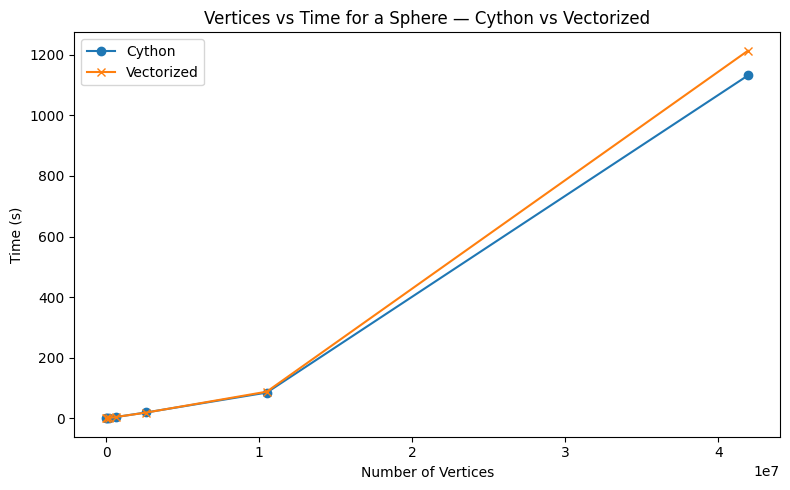

In [11]:
df_cython     = pd.read_csv('timing_summary_cython.csv')
df_vectorized = pd.read_csv('timing_summary_vectorized.csv')

plt.figure(figsize=(8, 5))
plt.plot(df_cython['n_vertices'],     df_cython['time_s'],     marker='o', label='Cython')
plt.plot(df_vectorized['n_vertices'], df_vectorized['time_s'], marker='x', label='Vectorized')
plt.xlabel('Number of Vertices')
plt.ylabel('Time (s)')
plt.title('Vertices vs Time for a Sphere — Cython vs Vectorized')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/timing_comparison_time_vs_vertices.png', dpi=150, bbox_inches='tight')
plt.show()

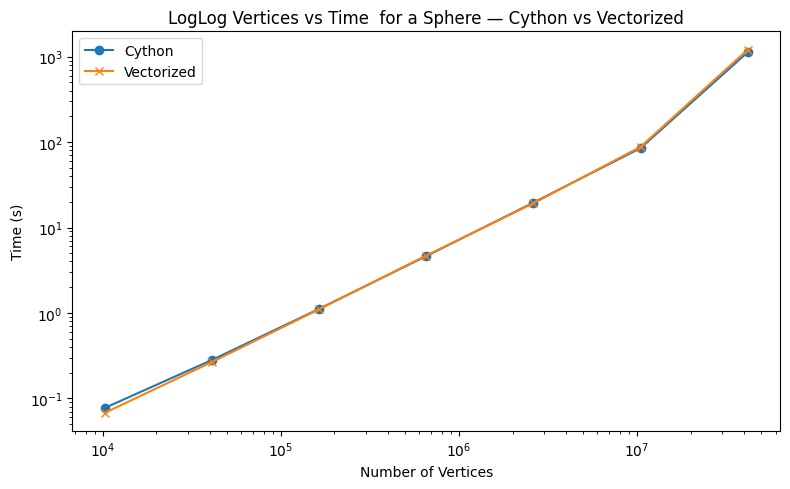

In [12]:
plt.figure(figsize=(8, 5))
plt.loglog(df_cython['n_vertices'],     df_cython['time_s'],     marker='o', label='Cython')
plt.loglog(df_vectorized['n_vertices'], df_vectorized['time_s'], marker='x', label='Vectorized')
plt.xlabel('Number of Vertices')
plt.ylabel('Time (s)')
plt.title('LogLog Vertices vs Time  for a Sphere — Cython vs Vectorized')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/loglog_timing_comparison_time_vs_vertices.png', dpi=150, bbox_inches='tight')
plt.show()

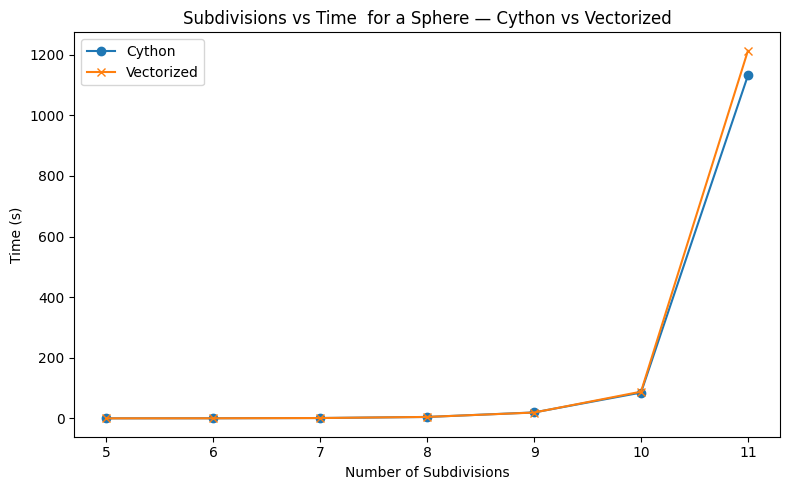

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(df_cython['subdivision'],     df_cython['time_s'],     marker='o', label='Cython')
plt.plot(df_vectorized['subdivision'], df_vectorized['time_s'], marker='x', label='Vectorized')
plt.xlabel('Number of Subdivisions')
plt.ylabel('Time (s)')
plt.title('Subdivisions vs Time  for a Sphere — Cython vs Vectorized')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/timing_comparison_time_vs_subdivisions.png', dpi=150, bbox_inches='tight')
plt.show()